# Customer Churn Analysis using Python

## Objective

The objective of this project is to analyze customer churn using the Telco Customer Churn dataset. This analysis aims to identify the customer characteristics and service-related factors associated with churn, helping businesses improve customer retention through data-driven insights.

## Dataset

Source:
Telco Customer Churn Dataset (Kaggle)

The dataset contains information about:

- Customer demographics(Gender, Senior Citizen, Partner, Dependents)
- Internet services
- Phone services
- Contract type
- Monthly charges
- Total charges
- Payment method
- Customer churn status

Total Records: 7043

Target Variable:
Churn (Yes/No)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Telco_customer_churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

## Data Understanding

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


## Data Cleaning

In [8]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [11]:
df["TotalCharges"].head(15)

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65
5,820.5
6,1949.4
7,301.9
8,3046.05
9,3487.95


In [12]:
df["TotalCharges"].tail(15)

,TotalCharges
7028,4326.25
7029,263.05
7030,39.25
7031,3316.1
7032,75.75
7033,2625.25
7034,6886.25
7035,1495.1
7036,743.3
7037,1419.4


In [13]:
(df["TotalCharges"]==" ").sum()

np.int64(11)

In [14]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

In [15]:
df["TotalCharges"].dtype

dtype('float64')

In [16]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [17]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [18]:
df=df.dropna()

In [19]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### Summary of Data Cleaning

- Checked missing values
- Checked duplicate records
- Converted TotalCharges to numeric format
- Removed rows with missing values
- Verified the cleaned dataset

In [20]:
df["Churn"].value_counts()

,count
Churn,
No,5163
Yes,1869


In [21]:
df["Churn"].value_counts(normalize=True).mul(100).round(2)

,proportion
Churn,
No,73.42
Yes,26.58


## Exploratory Data Analysis (EDA)

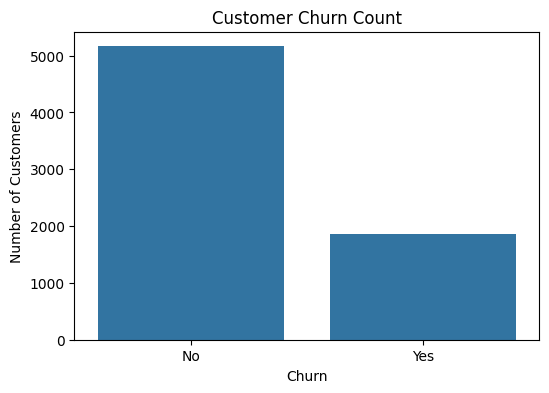

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn",data=df)
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Count")
plt.show()

About 26-27% of customers in this dataset have churned, while the rest have stayed. This class imbalance is something to keep in mind for any future modeling.

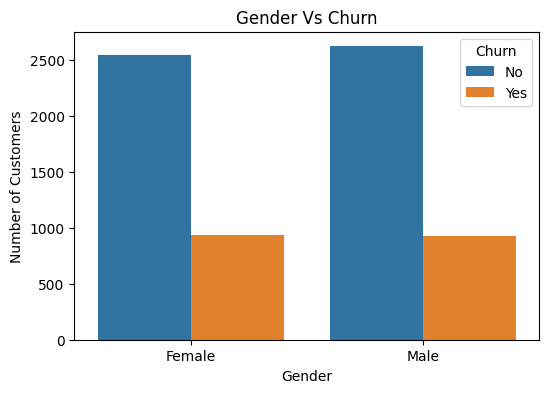

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender",hue="Churn",data=df)
plt.title("Gender Vs Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

Churn rates are nearly identical for male and female customers, suggesting gender is not a meaningful predictor of churn.

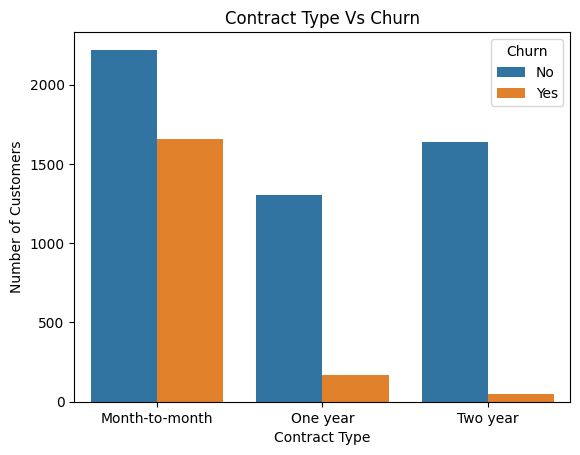

In [24]:
sns.countplot(x="Contract",hue="Churn",data=df)
plt.title("Contract Type Vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

Customers on month-to-month contracts churn far more than those on one or two-year contracts. Longer commitment plans appear to strongly reduce churn risk.

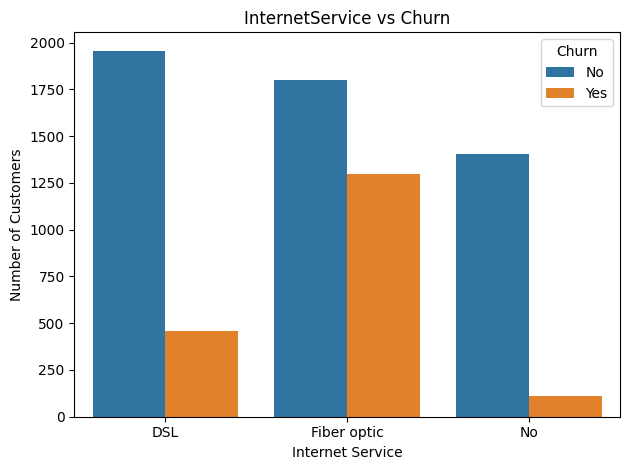

In [25]:
sns.countplot(x="InternetService",hue="Churn",data=df)
plt.title("InternetService vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

Customers with Fiber optic internet churn more than those with DSL or no internet service, possibly due to higher pricing or service issues with fiber.

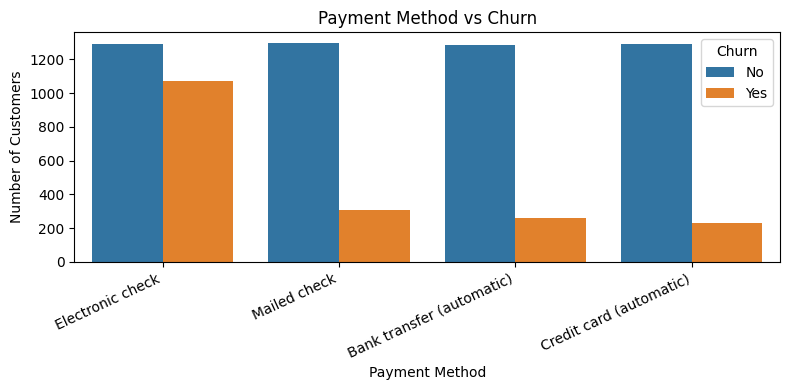

In [26]:
plt.figure(figsize=(8,4))
sns.countplot(x="PaymentMethod",hue="Churn",data=df)
plt.title("Payment Method vs Churn")
plt.xlabel("Payment Method")
plt.xticks(rotation=25,ha="right")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

Customers who pay via Electronic check churn at a noticeably higher rate than those using automatic bank transfer or credit card payments.

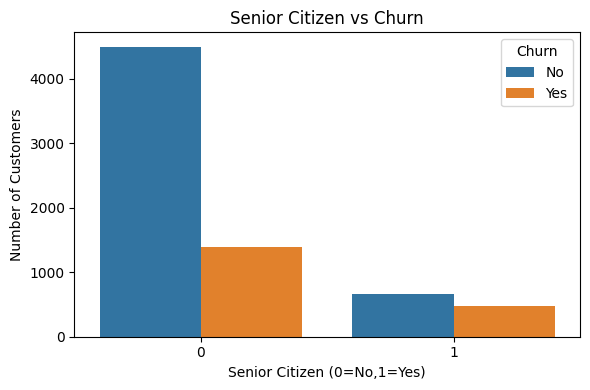

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x="SeniorCitizen",hue="Churn",data=df)
plt.title("Senior Citizen vs Churn")
plt.xlabel("Senior Citizen (0=No,1=Yes)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

Senior citizens churn at a higher rate than non-senior customers, suggesting age-related service or pricing concerns.

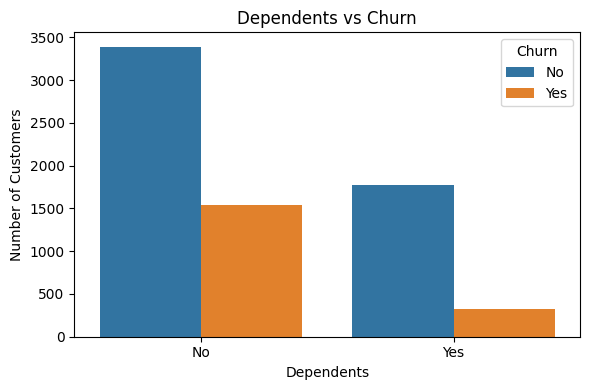

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(x="Dependents",hue="Churn",data=df)
plt.title("Dependents vs Churn")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

Customers without dependents churn more than those with dependents, possibly because family plans create more reasons to stay.

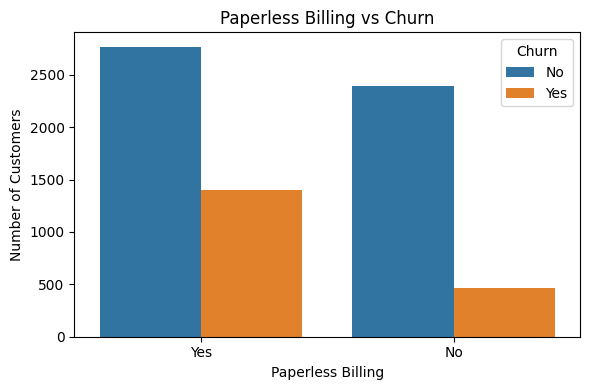

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(x="PaperlessBilling",hue="Churn",data=df)
plt.title("Paperless Billing vs Churn")
plt.xlabel("Paperless Billing")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

Customers using paperless billing churn more than those using paper billing, which is a bit counterintuitive and worth noting as an observation rather than a strong driver.

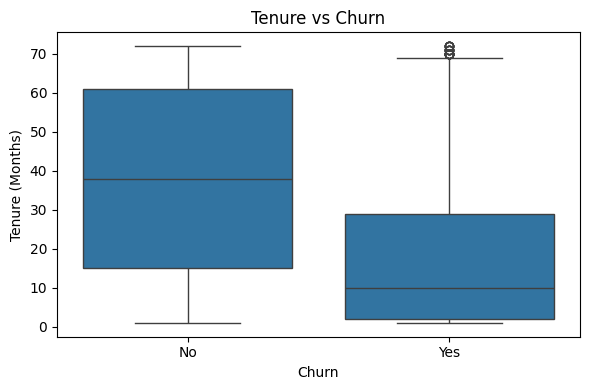

In [30]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn",y="tenure",data=df)
plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.tight_layout()
plt.show()

Customers who churn tend to have much shorter tenure, meaning churn is highest among newer customers.

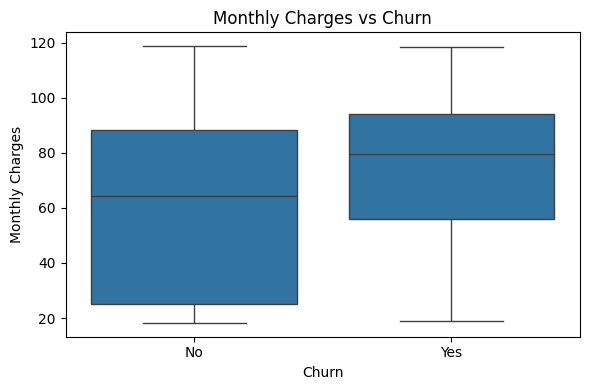

In [31]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn",y="MonthlyCharges",data=df)
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

Customers with higher monthly charges are more likely to churn than those paying less per month.

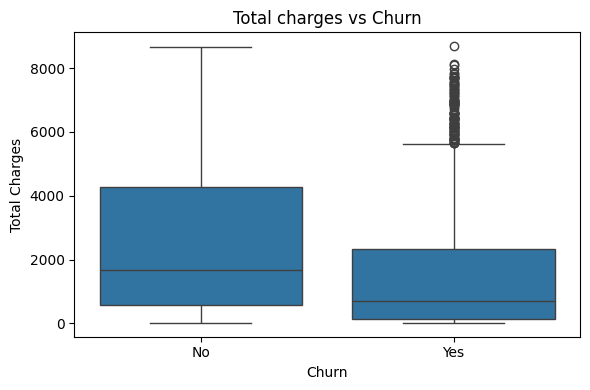

In [32]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn",y="TotalCharges",data=df)
plt.title("Total charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.tight_layout()
plt.show()

Customers who churn tend to have lower total charges overall, which lines up with them having shorter tenure.

In [33]:
df["Churn_num"]=df["Churn"].map({"No":0,"Yes":1})

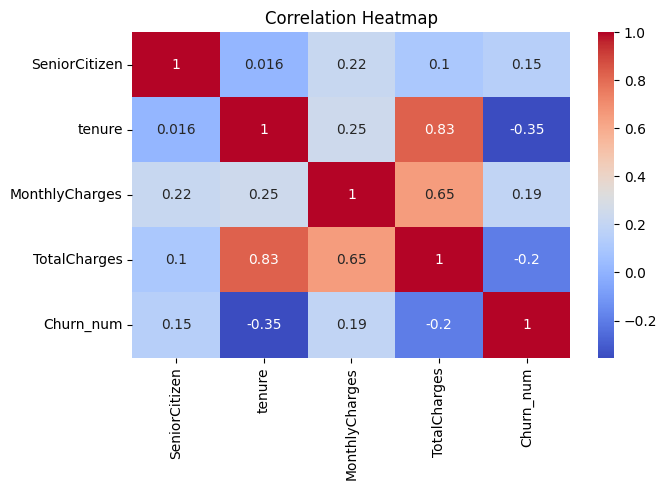

In [34]:
plt.figure(figsize=(7,5))
corr = df[["SeniorCitizen","tenure","MonthlyCharges","TotalCharges","Churn_num"]].corr()
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Tenure has the strongest negative correlation with churn, while Monthly Charges has a positive correlation. This confirms what we saw in the boxplots above.

## Key Insights

1. About one-fourth of the customers have churned, while most customers stayed with the company.

2. Customers with month-to-month contracts are more likely to leave than customers with one-year or two-year contracts.

3. Customers with shorter tenure have a higher chance of churning, while customers with longer tenure are more likely to stay.

4. Customers using Fiber Optic internet service have a higher churn rate compared to customers using other internet services.

5. Customers who use Electronic Check as their payment method have a higher churn rate than customers using other payment methods.

6. Customers with higher monthly charges are more likely to churn.

7. Senior citizens and customers without dependents show slightly higher churn rates than other customer groups.



## Business Recommendations
1. Encourage customers to choose one-year or two-year contracts by offering discounts or special benefits.

2. Focus on retaining new customers by providing better support during their first few months.

3. Review the pricing and service quality of Fiber Optic internet plans to improve customer satisfaction.

4. Encourage customers to use automatic payment methods instead of Electronic Check by offering small incentives.

5. Identify customers with high monthly charges and provide personalized offers or discounts to reduce churn.

6. Reward long-term customers with loyalty programs to encourage them to stay with the company.

7. Focus on senior citizens and customers without dependents by offering better support and personalized plans to improve customer retention.

## Conclusion

In this project, I analyzed the Telco Customer Churn dataset using Python to understand the factors that influence customer churn. After cleaning the data and performing exploratory data analysis, I found that contract type, tenure, internet service, payment method, and monthly charges are the main factors related to customer churn. I also observed that senior citizens and customers without dependents showed slightly higher churn rates.

Based on these findings, I suggested business recommendations such as encouraging long-term contracts, improving support for new customers, reviewing Fiber Optic plans, and offering personalized retention strategies. This project demonstrates my ability to clean data, analyze trends, create visualizations, and generate business insights using Python.